## Import packages

In [61]:
# If using Google Colab, uncomment the following line
# !pip install rasterio

import sys
print(sys.version)  # Print Python version in use

import numpy as np                                      # Array operations
import matplotlib.pyplot as plt                         # Plotting library
import torch                                            # Main PyTorch library
import torch.optim as optim                             # Optimization algorithms
import torch.nn as nn                                   # Neural network modules
import os                                               # Operating system utilities
import glob                                             # File path pattern matching
import pandas as pd                                     # Data manipulation
import rasterio                                         # Geospatial raster data

from datetime import datetime, timedelta                # Date/time utilities
from rasterio.plot import show                          # Plot raster data	

import deepSSF_model                                    # Import the deepSSF model
import deepSSF_utils                                    # Import the deepSSF utilities

# Get today's date
today_date = datetime.today().strftime('%Y-%m-%d')
print("Today's date:", today_date)  # Print today's date

3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:12) [Clang 14.0.6 ]
Today's date: 2025-06-13


### If using Google Colab, uncomment the following lines

The file directories will also need to be changed to match the location of the files in your Google Drive.

In [62]:
# from google.colab import drive
# drive.mount('/content/drive')

## Import the GPS data

We only use this for selecting a spatial extent for the area we want to predict over.

In [63]:
window_size = 151  # Define the window size for the model

# Specify the path to your CSV file
csv_file_path = f'../data/buffalo_djelk_all_steps_nxn{window_size}.csv'

# Read the CSV file into a DataFrame
# When reading from a CSV file, use parse_dates parameter to specify the columns that contain datetimes
buffalo_df = pd.read_csv(csv_file_path, parse_dates=['t1_', 't2_'])

# Count the number of rows in the DataFrame
num_rows = buffalo_df.shape[0]
print(f"Number of rows in the DataFrame: {num_rows}")  # Print number of rows

# Verify the timezone info
print(buffalo_df['t1_'].dt.tz)  # Should show UTC

# Convert from UTC to Australia/Queensland timezone
buffalo_df['t1_'] = buffalo_df['t1_'].dt.tz_convert('Australia/Queensland')
buffalo_df['t2_'] = buffalo_df['t2_'].dt.tz_convert('Australia/Queensland')

# Create an integer representation of the time 
buffalo_df['t1_int'] = buffalo_df['t1_'].astype(np.int64).values
buffalo_df['t2_int'] = buffalo_df['t2_'].astype(np.int64).values

# Display the first few rows of the DataFrame
print(buffalo_df.head())

Number of rows in the DataFrame: 105763
UTC
     id           x1_           x2_           y1_           y2_         sl_  \
0  2005  41969.310875  41921.521939 -1.435671e+06 -1.435654e+06   50.674891   
1  2005  41921.521939  41779.439594 -1.435654e+06 -1.435601e+06  151.845214   
2  2005  41779.439594  41841.203272 -1.435601e+06 -1.435635e+06   70.659861   
3  2005  41841.203272  41655.463332 -1.435635e+06 -1.435604e+06  188.309703   
4  2005  41655.463332  41618.651923 -1.435604e+06 -1.435608e+06   37.077972   

   direction_p       ta_                       t1_                       t2_  \
0     2.802478  1.367942 2018-07-25 11:04:23+10:00 2018-07-25 12:04:39+10:00   
1     2.781049 -0.021429 2018-07-25 12:04:39+10:00 2018-07-25 13:04:17+10:00   
2    -0.507220  2.994917 2018-07-25 13:04:17+10:00 2018-07-25 14:04:39+10:00   
3     2.976198 -2.799767 2018-07-25 14:04:39+10:00 2018-07-25 15:04:27+10:00   
4    -3.021610  0.285377 2018-07-25 15:04:27+10:00 2018-07-25 16:04:24+10:00   



### Check the time component of the GPS data

In [64]:
# time of a single location
print(buffalo_df['t1_'].iloc[0].strftime('%Y-%m-%d %H:%M:%S %Z'))

2018-07-25 11:04:23 AEST


# Importing spatial data

Instead of importing the stacks of local layers (one for each step), here we want to import the full spatial covariates that we can chop the local layers out from. We use an extent that covers all of the observed locations, which refer to as the 'landscape'.

## Sentinel-2 bands

Each stack represents a month of median values of cloud-free pixels, and each layer in the stack are the bands.

During the data preparation all of these layers were scaled by 10,000, and don't need to be scaled any further.

In [65]:
# Specify the directory containing your TIFF files
data_dir = '../mapping/cropped rasters/sentinel2/25m'  # Replace with the actual path to your TIFF files

# Use glob to get a list of all TIFF files matching the pattern
tif_files = glob.glob(os.path.join(data_dir, 'S2_SR_masked_25m_*.tif'))
print(f'Found {len(tif_files)} TIFF files')
print('\n'.join(tif_files))

Found 12 TIFF files
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_09.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_08.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_12.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_06.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_07.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_05.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_11.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_10.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_04.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_01.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_03.tif
../mapping/cropped rasters/sentinel2/25m/S2_SR_masked_25m_2019_02.tif


In [66]:
# Initialise a dictionary to store data with date as the key
data_dict = {}

# Loop over each TIFF file to read and process the data
for tif_file in tif_files:
    # Extract the filename from the path
    filename = os.path.basename(tif_file)
    
    # Extract the date from the filename
    # Assuming filenames are in the format 'S2_SR_masked_YYYY_MM.tif'
    date_str = filename.replace('S2_SR_masked_25m_', '').replace('.tif', '')
    # date_str will be something like '2019_01'
    
    # Read the TIFF file using rasterio
    with rasterio.open(tif_file) as src:
        # Read all bands of the TIFF file
        data = src.read()
        # 'data' is a NumPy array with shape (bands, height, width)

        # Count the number of cells that are NaN
        n_nan = np.isnan(data).sum()

        print(f"Date: {date_str}")
        print(f"Number of NaN values in {date_str}: {n_nan}")
        print(f'Proportion of NaN values: {n_nan / data.size:.4%}\n')

        # Replace NaN values with zeros	
        data = np.nan_to_num(data, nan=0)
        data = data / 10000
        
        # Add the data to the dictionary with date as the key
        data_dict[date_str] = data


Date: 2019_09
Number of NaN values in 2019_09: 36
Proportion of NaN values: 0.0001%

Date: 2019_08
Number of NaN values in 2019_08: 144
Proportion of NaN values: 0.0002%

Date: 2019_12
Number of NaN values in 2019_12: 0
Proportion of NaN values: 0.0000%

Date: 2019_06
Number of NaN values in 2019_06: 144
Proportion of NaN values: 0.0002%

Date: 2019_07
Number of NaN values in 2019_07: 96
Proportion of NaN values: 0.0001%

Date: 2019_05
Number of NaN values in 2019_05: 144
Proportion of NaN values: 0.0002%

Date: 2019_11
Number of NaN values in 2019_11: 48
Proportion of NaN values: 0.0001%

Date: 2019_10
Number of NaN values in 2019_10: 0
Proportion of NaN values: 0.0000%

Date: 2019_04
Number of NaN values in 2019_04: 13296
Proportion of NaN values: 0.0202%

Date: 2019_01
Number of NaN values in 2019_01: 2460
Proportion of NaN values: 0.0037%

Date: 2019_03
Number of NaN values in 2019_03: 478731
Proportion of NaN values: 0.7291%

Date: 2019_02
Number of NaN values in 2019_02: 420
Prop

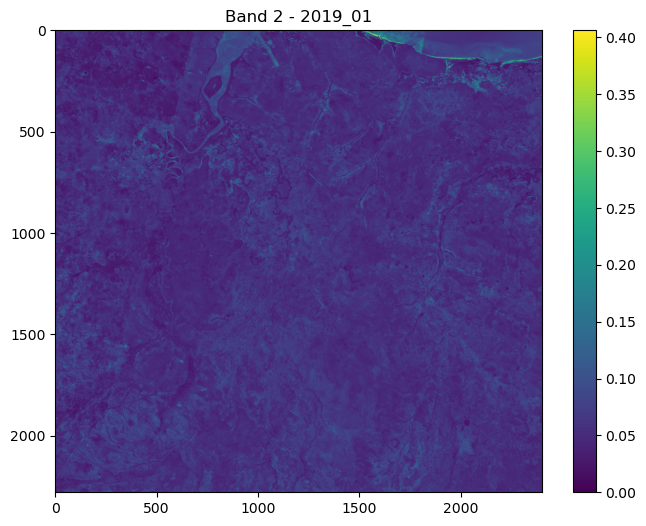

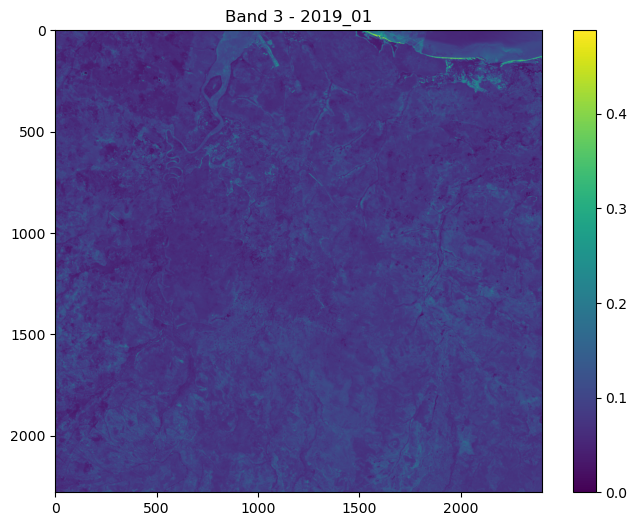

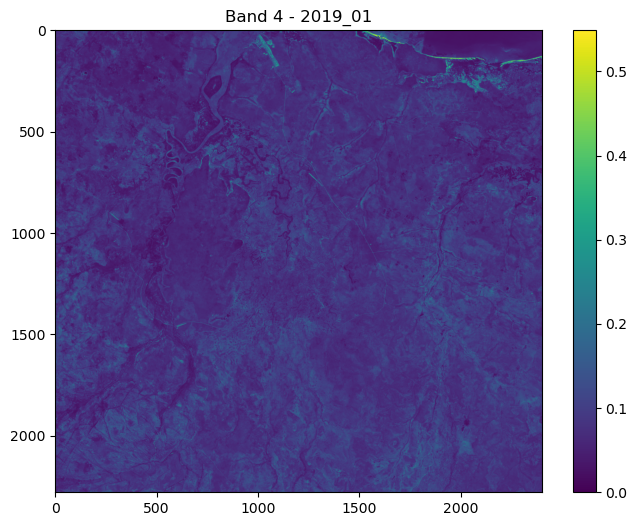

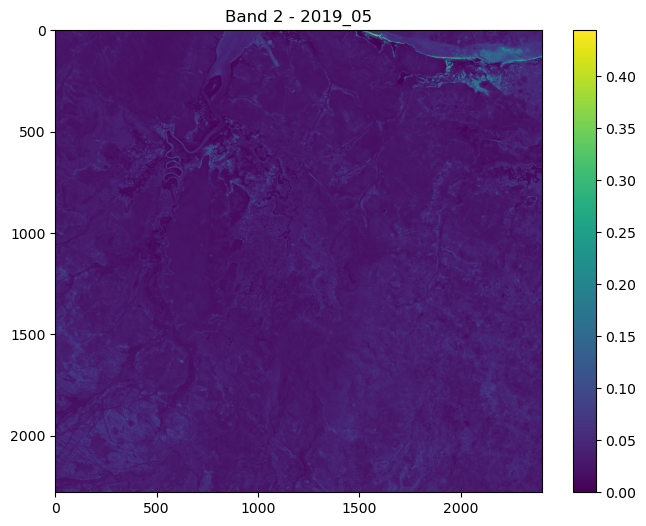

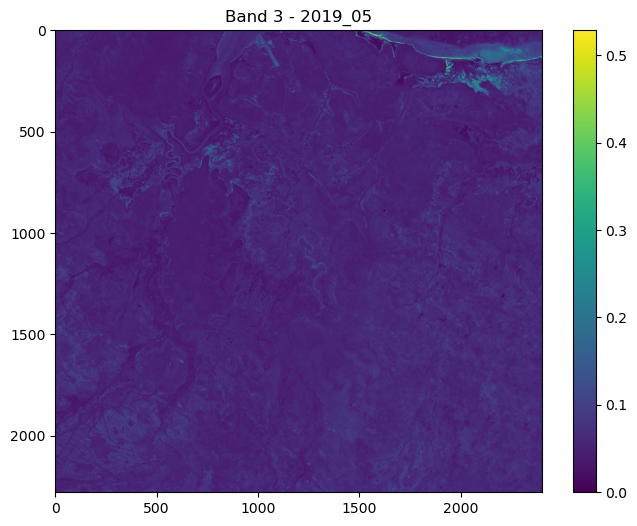

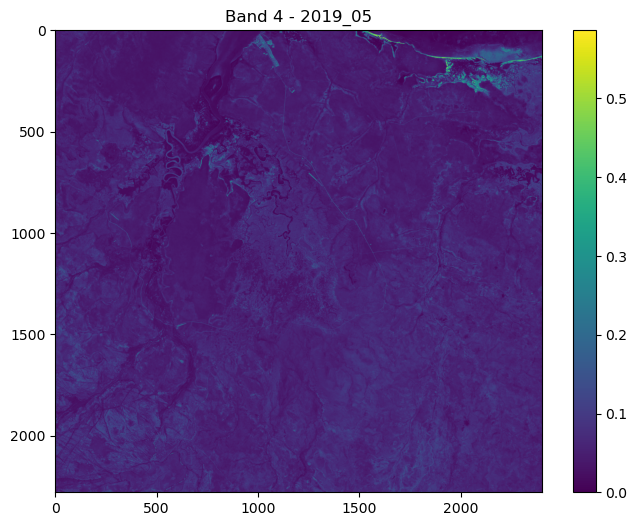

In [67]:
# Select some bands from the processed data stored in 'data_dict' for plotting
layers_to_plot = []

# Specify the date and band numbers you want to plot
dates_to_plot = ['2019_01', '2019_05']  # This grabs all available dates. You can select specific ones if needed.
bands_to_plot = [1, 2, 3]  # Band indices for bands 2, 3, and 4, which are B, G, and R

# Loop through the selected dates and bands to prepare them for plotting
for date_str in dates_to_plot:
    data = data_dict[date_str]  # Get the normalized data for this date
    
    for band_idx in bands_to_plot:
        # Collect the specific band for plotting
        layers_to_plot.append((data[band_idx], band_idx + 1, date_str))

# Plot the stored layers
for band, band_number, date_str in layers_to_plot:
    plt.figure(figsize=(8, 6))
    plt.imshow(band, cmap='viridis') 
    plt.title(f'Band {band_number} - {date_str}')
    plt.colorbar() #label='Normalized Value'
    plt.show()


### Plot as RGB

We can also visualise the Sentinel-2 bands as an RGB image, using the Red, Green and Blue bands.

The plotting was a bit dark so we will adjust the brightness of the image using a gamma correction.

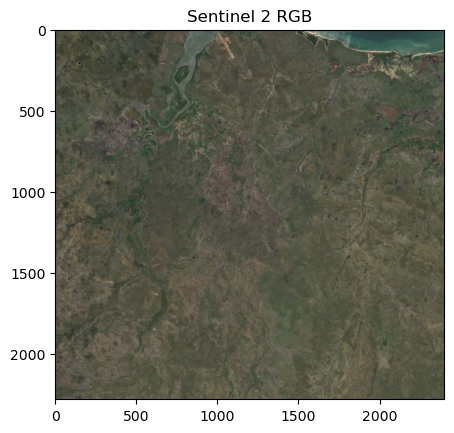

In [68]:
# Specify the date for the RGB layers
date_str = '2019_01'  

# pull out the RGB bands
r_band = data_dict[date_str][3]
g_band = data_dict[date_str][2]
b_band = data_dict[date_str][1]

# Stack the bands along a new axis
rgb_image = np.stack([r_band, g_band, b_band], axis=-1)
# Normalize to the range [0, 1] for display
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

# Apply gamma correction to the image
gamma = 1.75
rgb_image = rgb_image ** (1/gamma)

plt.figure()  # Create a new figure
plt.imshow(rgb_image)
plt.title('Sentinel 2 RGB')
plt.draw()  # Ensure the plot is rendered
plt.show()
plt.close()  # Close the figure to free memory

## Slope

In [69]:
# Path to the slope raster file
file_path = '../mapping/cropped rasters/slope.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    slope_landscape = src.read(1)
    # Get the metadata of the raster
    slope_meta = src.meta
    raster_transform = src.transform 

Slope metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of slope landscape raster:
(2280, 2400)


Number of NA values in the slope raster:
9356
Minimum slope 

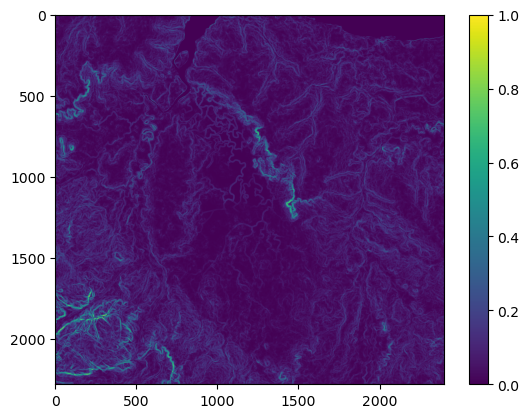

In [70]:
# Check the slope metadata:
print("Slope metadata:")
print(slope_meta)
print("\n")

# Check the shape (rows, columns) of the slope landscape raster:
print("Shape of slope landscape raster:")
print(slope_landscape.shape)
print("\n")

# Check for NA values in the slope raster:
print("Number of NA values in the slope raster:")
print(np.isnan(slope_landscape).sum())

# Replace NaNs in the slope array with 0.0:
slope_landscape = np.nan_to_num(slope_landscape, nan=0.0)

# Define the maximum and minimum slope values from the stack of local layers:
slope_min = np.min(slope_landscape)
slope_max = np.max(slope_landscape)
print(f'Minimum slope value: {slope_min}')
print(f'Maximum slope value: {slope_max}')

# Normalize the slope landscape data:
slope_landscape_norm = (slope_landscape - slope_min) / (slope_max - slope_min)

# Visualize the slope landscape (note: displaying the original tensor, not the normalised data):
plt.imshow(slope_landscape_norm)
plt.colorbar()
plt.show()


### Convert between numpy array and raster

To check that we can go back and forth between numpy arrays (with pixel coordinates) and rasters (with geographic coordinates), we will convert the slope numpy array to a raster. 

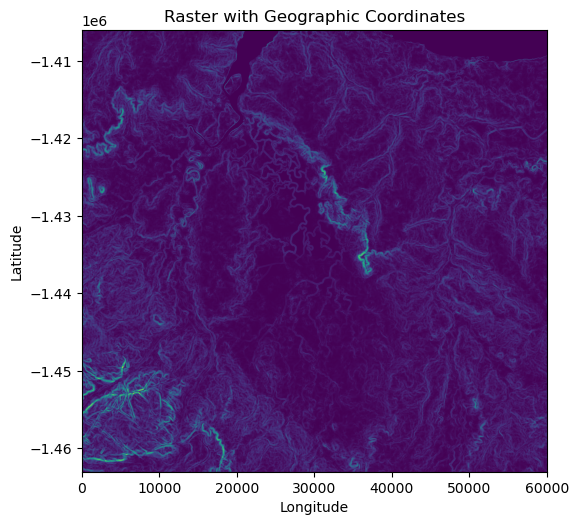

In [71]:
# Create a figure and axis with matplotlib
fig, ax = plt.subplots(figsize=(6, 6))

# Convert the slope_landcape (numpy array) to a raster and plot with the rasterio library
rasterio.plot.show(slope_landscape, transform=raster_transform, ax=ax, cmap='viridis')

# Set the title and labels
ax.set_title('Raster with Geographic Coordinates')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the plot
plt.show()

# Subset function (with padding)

Now that we have our landscape layers imported, we need a way to crop out the local layers that can be saved for training the deepSSF model.

We will use the same subset function as in the deepSSF simulation notebook, which we stored in the `deepSSF_utils.py` script. This function will take the landscape layers and a set of coordinates, and return the local layers for those coordinates.

This function also has padding for if the simulated individual was to go off the edge of the landscape, which we retain here (although we should not need that functionality).

In [72]:
subset_raster = deepSSF_utils.subset_raster_with_padding_npy
subset_raster

<function deepSSF_utils.subset_raster_with_padding_npy(raster_npy, x, y, window_size, transform)>

### Testing the subset function

Use the subset function to crop out the local layers for all covariates. Try different locations using the x and y coordinates, which are in geographic coordinates (x = easting/longitude, y = northing/latitude).

Buffalo location: 46735.93659954723, -1432245.0839189908
(12, 2280, 2400)
Distance between locations: -76.52170596739597, -145.80412439908832
x1 pixel coordinates: 1869.4374639818893, 1049.8033567596358
x1 pixel coordinates (floored): 1869, 1049
Target pixel coordinates: 1866.3765957431935, 1055.6355217355958
Target pixel coordinates (floored): 1866, 1055
Distance between pixels: -3, 6
Target pixel using origin: 72, 81
Target pixel using distance in pixel coords: 47, 56


Text(0.5, 1.0, 'Slope Subset')

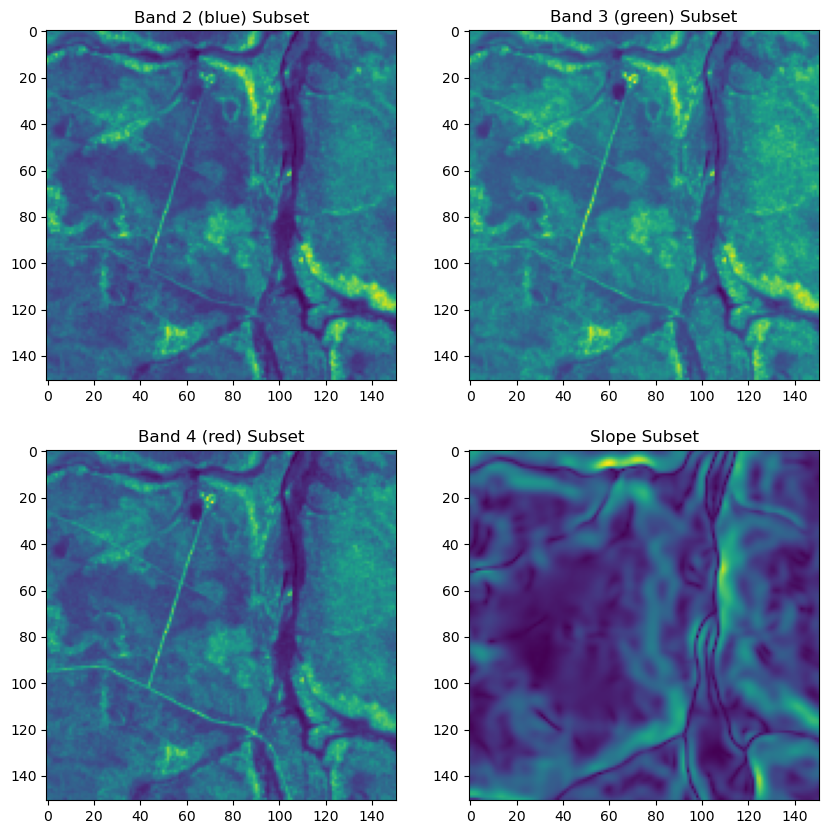

In [73]:
# Define the size of the window to extract
window_size = 151  

location_index = 2000

# Pick a location (x, y) from the buffalo DataFrame
x = buffalo_df['x1_'].iloc[location_index]
y = buffalo_df['y1_'].iloc[location_index]

print(f'Buffalo location: {x}, {y}')

# For sentinel 2 data
selected_month = '2019_01'
# Get the data for the selected month
s2_data = data_dict[selected_month]

# Convert the NumPy array to a PyTorch tensor
s2_month = s2_data
# s2_month = s2_month.float()  # Ensure the tensor is of type float
print(s2_month.shape) # [bands, height, width]

# Extract subsets from various raster layers using the custom function.
# Each call centres the window at the specified (x, y) location and applies padding where necessary.

# Get the subset of the Sentinel-2 bands
s2_b1_subset, origin_x, origin_y = subset_raster(s2_month[0,:,:], x, y, window_size, raster_transform)
s2_b2_subset, origin_x, origin_y = subset_raster(s2_month[1,:,:], x, y, window_size, raster_transform)
s2_b3_subset, origin_x, origin_y = subset_raster(s2_month[2,:,:], x, y, window_size, raster_transform)
s2_b4_subset, origin_x, origin_y = subset_raster(s2_month[3,:,:], x, y, window_size, raster_transform)
s2_b5_subset, origin_x, origin_y = subset_raster(s2_month[4,:,:], x, y, window_size, raster_transform)
s2_b6_subset, origin_x, origin_y = subset_raster(s2_month[5,:,:], x, y, window_size, raster_transform)
s2_b7_subset, origin_x, origin_y = subset_raster(s2_month[6,:,:], x, y, window_size, raster_transform)
s2_b8_subset, origin_x, origin_y = subset_raster(s2_month[7,:,:], x, y, window_size, raster_transform)
s2_b8a_subset, origin_x, origin_y = subset_raster(s2_month[8,:,:], x, y, window_size, raster_transform)
s2_b9_subset, origin_x, origin_y = subset_raster(s2_month[9,:,:], x, y, window_size, raster_transform)
s2_b11_subset, origin_x, origin_y = subset_raster(s2_month[10,:,:], x, y, window_size, raster_transform)
s2_b12_subset, origin_x, origin_y = subset_raster(s2_month[11,:,:], x, y, window_size, raster_transform)

# Slope subset
slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm, 
                                                 x, y, window_size, raster_transform)

# Target (also as a numpy array)
x2 = buffalo_df['x2_'].iloc[location_index]
y2 = buffalo_df['y2_'].iloc[location_index]

dx = x2 - x
dy = y2 - y
print(f'Distance between locations: {dx}, {dy}')

# Convert geographic coordinates to pixel coordinates using the inverse transform.
# The raster transform is defined when reading the raster file.

# print(f'Origin x and y: {origin_x}, {origin_y}')

px1, py1 = ~raster_transform * (x, y)
print(f'x1 pixel coordinates: {px1}, {py1}')
# Round the pixel coordinates to the nearest integers.
px1, py1 = int(np.floor(px1)), int(np.floor(py1))
print(f'x1 pixel coordinates (floored): {px1}, {py1}')

target_px, target_py = ~raster_transform * (x2, y2)
print(f'Target pixel coordinates: {target_px}, {target_py}')

# Round the pixel coordinates to the nearest integers.
target_px, target_py = int(np.floor(target_px)), int(np.floor(target_py))
print(f'Target pixel coordinates (floored): {target_px}, {target_py}')

# Calculate the distance between the origin and target pixel coordinates.
dx = target_px - px1
dy = target_py - py1
print(f'Distance between pixels: {dx}, {dy}')

print(f'Target pixel using origin: {target_px - origin_x}, {target_py - origin_y}')

print(f'Target pixel using distance in pixel coords: {50+dx}, {50+dy}')

# Create a 2x2 grid of subplots with a fixed figure size.
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(s2_b2_subset, cmap='viridis')
axs[0, 0].set_title('Band 2 (blue) Subset')

axs[0, 1].imshow(s2_b3_subset, cmap='viridis')
axs[0, 1].set_title('Band 3 (green) Subset')

axs[1, 0].imshow(s2_b4_subset, cmap='viridis')
axs[1, 0].set_title('Band 4 (red) Subset')

axs[1, 1].imshow(slope_subset, cmap='viridis')
axs[1, 1].set_title('Slope Subset')

# Loop over all steps and save the local layers

## Create a directory to save the local layers

As some cloud storage systems (e.g. OneDrive) do not work well with many individual files (e.g. 100,000s of local layers), we will save the local layers on the hard drive, near the root of the C drive. We will create a directory to save the local layers in.

In [74]:
local_root_dir = f'/Users/scottforrest/deepSSF/nxn{window_size}' 
os.makedirs(local_root_dir, exist_ok=True)

# Create directories for the different covariates
local_s2_b1_dir = os.path.join(local_root_dir, 's2_b1')
local_s2_b2_dir = os.path.join(local_root_dir, 's2_b2')
local_s2_b3_dir = os.path.join(local_root_dir, 's2_b3')
local_s2_b4_dir = os.path.join(local_root_dir, 's2_b4')
local_s2_b5_dir = os.path.join(local_root_dir, 's2_b5')
local_s2_b6_dir = os.path.join(local_root_dir, 's2_b6')
local_s2_b7_dir = os.path.join(local_root_dir, 's2_b7')
local_s2_b8_dir = os.path.join(local_root_dir, 's2_b8')
local_s2_b8a_dir = os.path.join(local_root_dir, 's2_b8a')
local_s2_b9_dir = os.path.join(local_root_dir, 's2_b9')
local_s2_b11_dir = os.path.join(local_root_dir, 's2_b11')
local_s2_b12_dir = os.path.join(local_root_dir, 's2_b12')

# Slope and target
local_slope_dir = os.path.join(local_root_dir, 'slope') 
local_target_dir = os.path.join(local_root_dir, 'target')

# Create the directories
os.makedirs(local_s2_b1_dir, exist_ok=True)
os.makedirs(local_s2_b2_dir, exist_ok=True)
os.makedirs(local_s2_b3_dir, exist_ok=True)
os.makedirs(local_s2_b4_dir, exist_ok=True)
os.makedirs(local_s2_b5_dir, exist_ok=True)
os.makedirs(local_s2_b6_dir, exist_ok=True)
os.makedirs(local_s2_b7_dir, exist_ok=True)
os.makedirs(local_s2_b8_dir, exist_ok=True)
os.makedirs(local_s2_b8a_dir, exist_ok=True)
os.makedirs(local_s2_b9_dir, exist_ok=True)
os.makedirs(local_s2_b11_dir, exist_ok=True)    
os.makedirs(local_s2_b12_dir, exist_ok=True)

# Create directories for slope and target
os.makedirs(local_slope_dir, exist_ok=True)
os.makedirs(local_target_dir, exist_ok=True)

## Check the number of steps in the trajectory

In [75]:
len(buffalo_df)

105763

## Index S2 layers correctly

We need to index the Sentinel-2 layers correctly, based on the time of the simulated location. We'll do this by creating a function that takes day of the year of the simulated location and returns the correct index for the Sentinel-2 layers.

This indexing is slightly different from the indexing we used for the `deepSSF_simulations.ipynb` notebook, which was indexing NDVI layers. In that case we were indexing the layers directly, and therefore the first entry was at 0 (i.e., March was in month_index = 2). Here, we are creating a string that corresponds to the layer name, and therefore the first entry is at 1. (i.e., March will be at month_index = 3)

In [76]:
# Create a mapping from day of the year to month index
def day_to_month_index(day_of_year):
    # Calculate the year and the day within that year
    base_date = datetime(2019, 1, 1)
    date = base_date + timedelta(days=int(day_of_year) - 1)
    year_diff = date.year - base_date.year
    month_index = (date.month) + (year_diff * 12)  # month index (1-based)
    if month_index == 0:
        month_index += 1
    return month_index

yday = 35
month_index = day_to_month_index(yday)
print(month_index)

2


Total number of steps: 105763
[--------------------] 0%

Buffalo ID:                         2005
Step date:                          2018-07-25
Step hour:                          11.07
S2 index:                           2019_07
x1 pixel coordinates (floored):     1678, 1186
Target pixel coordinates (floored): 1676, 1186
x1 pixel indices:                   75, 75
Target pixel indices:               73, 75


[--------------------] 0%

Buffalo ID:                         2005
Step date:                          2018-07-25
Step hour:                          12.07
S2 index:                           2019_07
x1 pixel coordinates (floored):     1676, 1186
Target pixel coordinates (floored): 1671, 1184
x1 pixel indices:                   75, 75
Target pixel indices:               70, 73


[--------------------] 0%

Buffalo ID:                         2005
Step date:                          2018-07-25
Step hour:                          13.07
S2 index:                           2019_07
x1 

[###################-] 99%

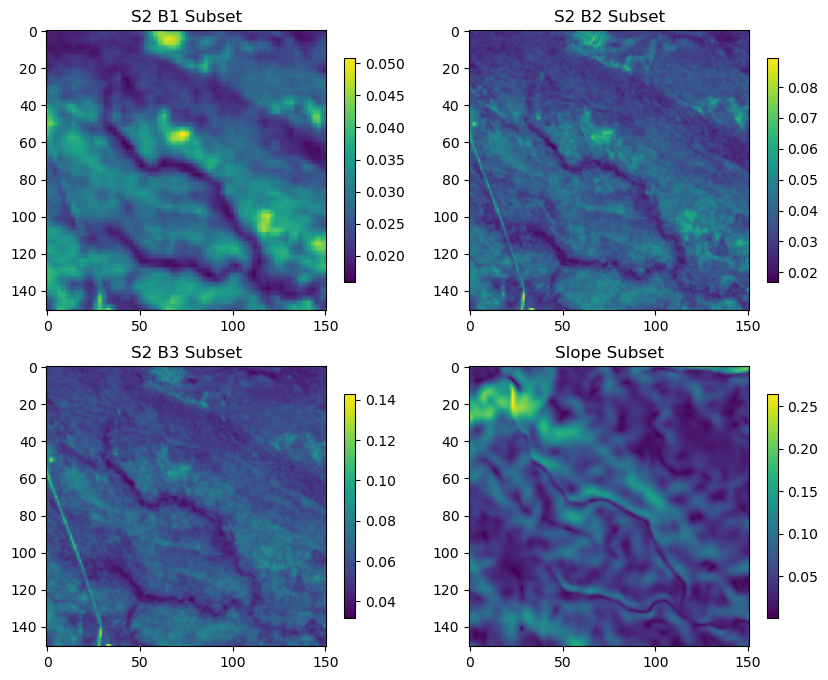

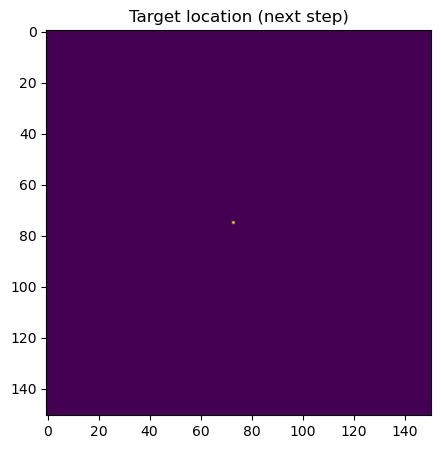

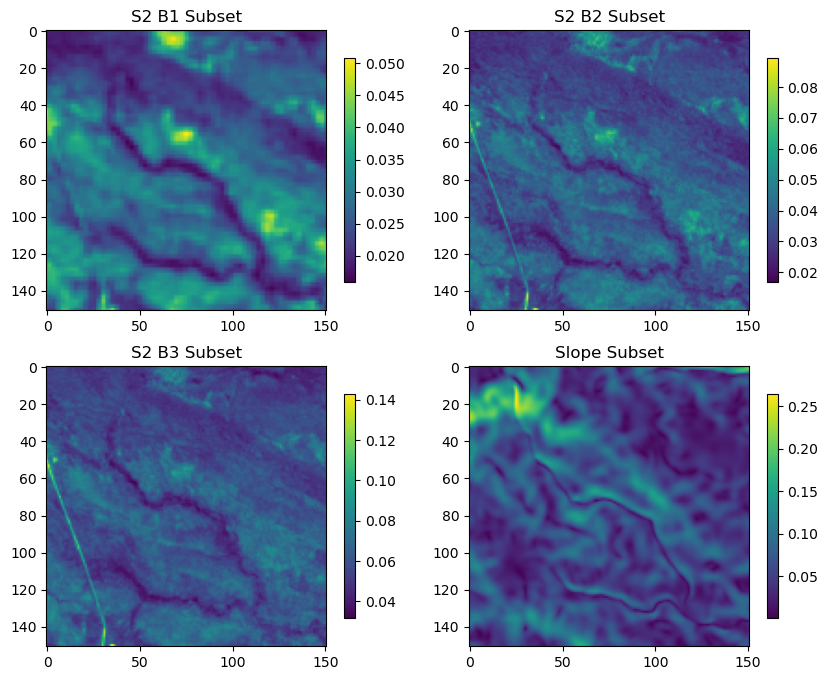

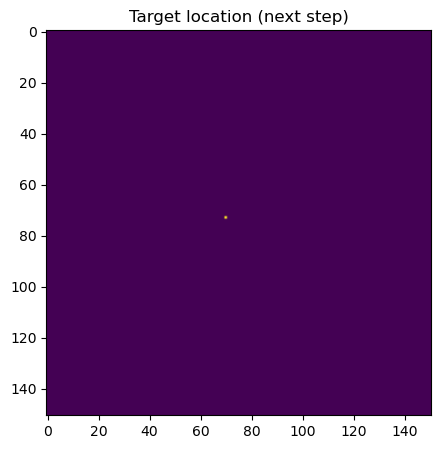

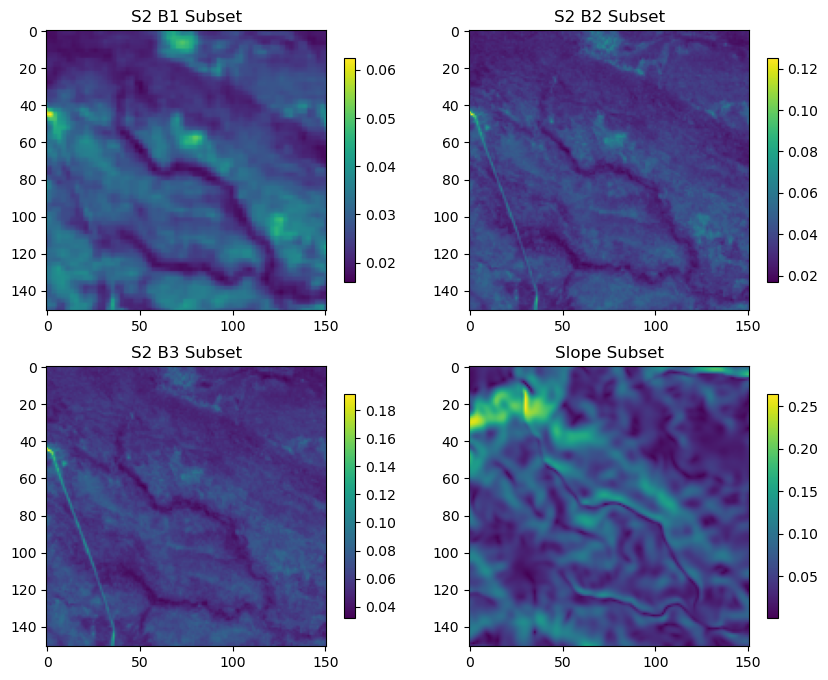

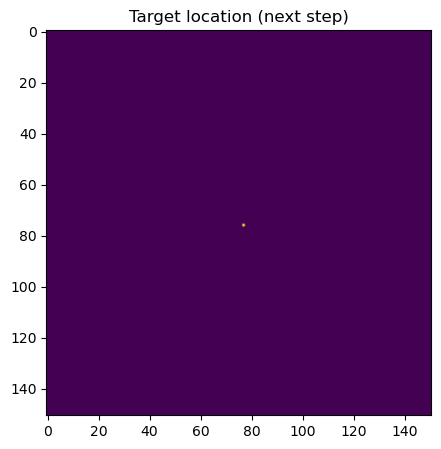

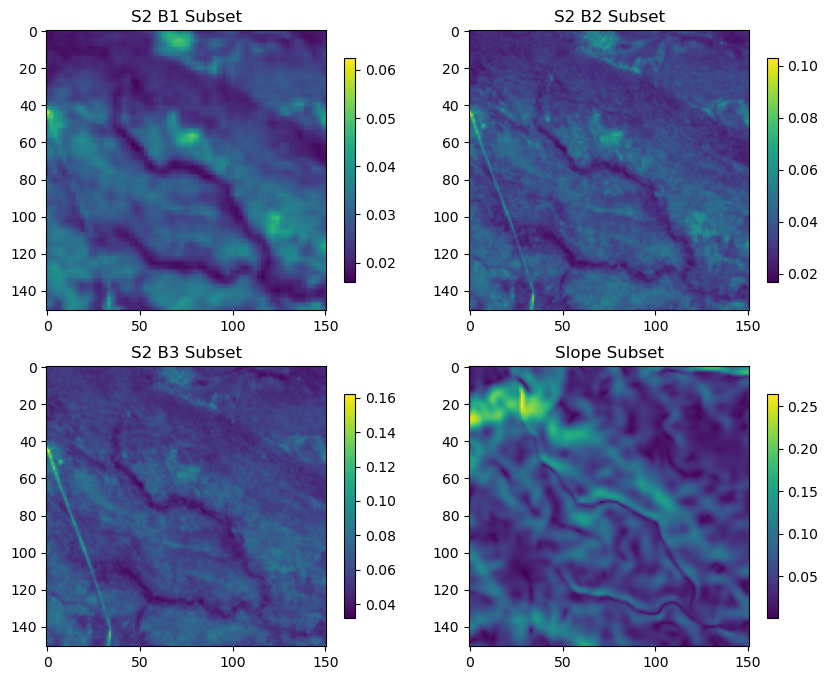

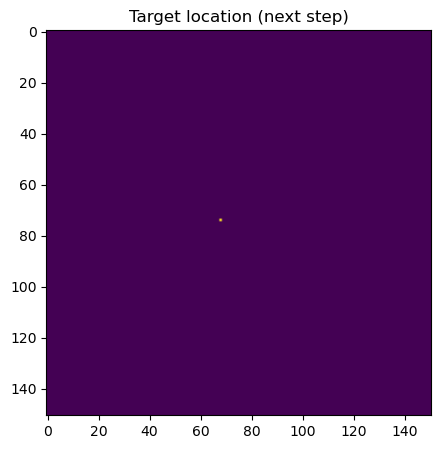

In [77]:
# Define the size of the window to extract
window_size = 151  

total_steps = len(buffalo_df)
print(f'Total number of steps: {total_steps}')

# total_steps = 1000

for location_index in range(total_steps): 
# for location_index in range(10): # for testing

    # Extract some info for saving the data
    buffalo_id = buffalo_df['id'].iloc[location_index]
    step_date = buffalo_df['t1_'].iloc[location_index].strftime('%Y-%m-%d')
    step_hour = buffalo_df['hour_t1'].iloc[location_index]
    yday = buffalo_df['yday_t1'].iloc[location_index]
    # print(f'Starting day of the year:     {yday}')
    
    # Get the month index from the day of the year
    month_index = day_to_month_index(yday)

    # for sentinel 2 data
    selected_month = f'2019_{month_index:02d}'
    # Get the normalized data for the selected month
    s2_month = data_dict[selected_month]
    # print(s2_month.shape)

    # Pick a location (x, y) from the buffalo DataFrame
    x = buffalo_df['x1_'].iloc[location_index]
    y = buffalo_df['y1_'].iloc[location_index]
    # print(f'Buffalo location: {x}, {y}')
    # Check that the current location is in the central cell of the local layers
    px1, py1 = ~raster_transform * (x, y)
    # Floor the pixel coordinates to get the pixel indices
    px1, py1 = int(np.floor(px1)), int(np.floor(py1))

    # Extract subsets from various raster layers using the custom function.
    # Each call centres the window at the specified (x, y) location and applies padding where necessary.

    # Get the subset of the Sentinel-2 bands
    s2_b1_subset, origin_x, origin_y = subset_raster(s2_month[0,:,:], x, y, window_size, raster_transform)
    s2_b2_subset, origin_x, origin_y = subset_raster(s2_month[1,:,:], x, y, window_size, raster_transform)
    s2_b3_subset, origin_x, origin_y = subset_raster(s2_month[2,:,:], x, y, window_size, raster_transform)
    s2_b4_subset, origin_x, origin_y = subset_raster(s2_month[3,:,:], x, y, window_size, raster_transform)
    s2_b5_subset, origin_x, origin_y = subset_raster(s2_month[4,:,:], x, y, window_size, raster_transform)
    s2_b6_subset, origin_x, origin_y = subset_raster(s2_month[5,:,:], x, y, window_size, raster_transform)
    s2_b7_subset, origin_x, origin_y = subset_raster(s2_month[6,:,:], x, y, window_size, raster_transform)
    s2_b8_subset, origin_x, origin_y = subset_raster(s2_month[7,:,:], x, y, window_size, raster_transform)
    s2_b8a_subset, origin_x, origin_y = subset_raster(s2_month[8,:,:], x, y, window_size, raster_transform)
    s2_b9_subset, origin_x, origin_y = subset_raster(s2_month[9,:,:], x, y, window_size, raster_transform)
    s2_b11_subset, origin_x, origin_y = subset_raster(s2_month[10,:,:], x, y, window_size, raster_transform)
    s2_b12_subset, origin_x, origin_y = subset_raster(s2_month[11,:,:], x, y, window_size, raster_transform)
    
    # Save the subset as npy files
    s2_b1_file_path = os.path.join(local_s2_b1_dir, f's2_b1_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b2_file_path = os.path.join(local_s2_b2_dir, f's2_b2_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b3_file_path = os.path.join(local_s2_b3_dir, f's2_b3_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b4_file_path = os.path.join(local_s2_b4_dir, f's2_b4_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b5_file_path = os.path.join(local_s2_b5_dir, f's2_b5_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b6_file_path = os.path.join(local_s2_b6_dir, f's2_b6_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b7_file_path = os.path.join(local_s2_b7_dir, f's2_b7_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b8_file_path = os.path.join(local_s2_b8_dir, f's2_b8_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b8a_file_path = os.path.join(local_s2_b8a_dir, f's2_b8a_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b9_file_path = os.path.join(local_s2_b9_dir, f's2_b9_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b11_file_path = os.path.join(local_s2_b11_dir, f's2_b11_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    s2_b12_file_path = os.path.join(local_s2_b12_dir, f's2_b12_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')

    np.save(s2_b1_file_path, s2_b1_subset)
    np.save(s2_b2_file_path, s2_b2_subset)  
    np.save(s2_b3_file_path, s2_b3_subset)
    np.save(s2_b4_file_path, s2_b4_subset)
    np.save(s2_b5_file_path, s2_b5_subset)  
    np.save(s2_b6_file_path, s2_b6_subset)
    np.save(s2_b7_file_path, s2_b7_subset)
    np.save(s2_b8_file_path, s2_b8_subset)
    np.save(s2_b8a_file_path, s2_b8a_subset)
    np.save(s2_b9_file_path, s2_b9_subset)
    np.save(s2_b11_file_path, s2_b11_subset)
    np.save(s2_b12_file_path, s2_b12_subset)

    # Slope subset
    slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm, x, y, window_size, raster_transform)
    slope_file_path = os.path.join(local_root_dir, f'slope/slop_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    np.save(slope_file_path, slope_subset)
    
    # Target (also as a numpy array)
    x2 = buffalo_df['x2_'].iloc[location_index]
    y2 = buffalo_df['y2_'].iloc[location_index]

    px2, py2 = ~raster_transform * (x2, y2)
    # print(f'Target pixel coordinates: {px2}, {py2}')
    # Floor the pixel coordinates to get the pixel indices
    px2, py2 = int(np.floor(px2)), int(np.floor(py2))
    next_step_x2 = px2 - origin_x
    next_step_y2 = py2 - origin_y

    # Create a square array of zeros with the given dimension
    target = np.zeros_like(slope_subset)
    target[next_step_y2, next_step_x2] = 1 # row, column

    # Save the target as an npy file
    target_file_path = os.path.join(local_root_dir, f'target/targ_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    np.save(target_file_path, target)

    # Update the csv file with the file paths
    buffalo_df.loc[location_index, 's2_b1_path'] = s2_b1_file_path
    buffalo_df.loc[location_index, 's2_b2_path'] = s2_b2_file_path
    buffalo_df.loc[location_index, 's2_b3_path'] = s2_b3_file_path
    buffalo_df.loc[location_index, 's2_b4_path'] = s2_b4_file_path
    buffalo_df.loc[location_index, 's2_b5_path'] = s2_b5_file_path
    buffalo_df.loc[location_index, 's2_b6_path'] = s2_b6_file_path
    buffalo_df.loc[location_index, 's2_b7_path'] = s2_b7_file_path
    buffalo_df.loc[location_index, 's2_b8_path'] = s2_b8_file_path
    buffalo_df.loc[location_index, 's2_b8a_path'] = s2_b8a_file_path
    buffalo_df.loc[location_index, 's2_b9_path'] = s2_b9_file_path
    buffalo_df.loc[location_index, 's2_b11_path'] = s2_b11_file_path
    buffalo_df.loc[location_index, 's2_b12_path'] = s2_b12_file_path
    buffalo_df.loc[location_index, 'slope_path'] = slope_file_path
    buffalo_df.loc[location_index, 'target_path'] = target_file_path

    # Progress bar
    # Calculate the percentage completed
    progress = location_index / total_steps
    # Create a simple bar representation (20 characters wide)
    bar_length = 20
    filled_length = int(bar_length * progress)
    bar = '#' * filled_length + '-' * (bar_length - filled_length)
    # Calculate the percentage as an integer
    percent = int(100 * progress)
    # Print the progress bar (overwrite the same line with \r)
    print(f'\r[{bar}] {percent}%', end='')

    # -------------------------------------------------------------------------
    # Plot some of the local rasters
    # -------------------------------------------------------------------------

    # Plot the first few probability surfaces
    if location_index < 4:

        print('\n')

        print(f'Buffalo ID:                         {buffalo_id}')
        print(f'Step date:                          {step_date}')
        print(f'Step hour:                          {step_hour}')
        print(f'S2 index:                           {selected_month}')
        print(f'x1 pixel coordinates (floored):     {px1}, {py1}')
        print(f'Target pixel coordinates (floored): {px2}, {py2}')
        print(f'x1 pixel indices:                   {px1 - origin_x}, {py1 - origin_y}')
        print(f'Target pixel indices:               {next_step_x2}, {next_step_y2}')
    
        print('\n')

        # Create a 2x2 grid of subplots with a fixed figure size.
        fig, axs = plt.subplots(2, 2, figsize=(10, 8))

        # Plot the NDVI subset
        im0 = axs[0, 0].imshow(s2_b1_subset, cmap='viridis')
        fig.colorbar(im0, ax=axs[0, 0], shrink=0.8)
        axs[0, 0].set_title('S2 B1 Subset')

        # Plot the Canopy Cover subset
        im1 = axs[0, 1].imshow(s2_b2_subset, cmap='viridis')
        fig.colorbar(im1, ax=axs[0, 1], shrink=0.8)
        axs[0, 1].set_title('S2 B2 Subset')

        # Plot the Herbaceous Vegetation subset
        im2 = axs[1, 0].imshow(s2_b3_subset, cmap='viridis')
        fig.colorbar(im2, ax=axs[1, 0], shrink=0.8)
        axs[1, 0].set_title('S2 B3 Subset')

        # Plot the Slope subset
        im3 = axs[1, 1].imshow(slope_subset, cmap='viridis')
        fig.colorbar(im3, ax=axs[1, 1], shrink=0.8)
        axs[1, 1].set_title('Slope Subset')

        # Also plot the target as a single plot
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(target, cmap='viridis')
        ax.set_title('Target location (next step)')
        
# Save the updated DataFrame to a new CSV file
buffalo_df.to_csv(f'{local_root_dir}/buffalo_djelk_nxn{window_size}_S2_all_steps_with_paths_n{total_steps}_steps.csv', index=False)